In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np 

In [14]:
# Chemins d'accès
CTD_PATH = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\Données brutes\CTD"
BARO_PATH = r'Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\1 - Données BARO\Gourdon baro\Patm Calès et Thémines.xlsx'
OLDDATA_PATH = "Y:/MISSIONS/Eau/1 - Projet Hydrogéologique Ouysse/3 - Hydrodynamique/0 - Stations en continu/Ouysse - Calès/"
METADATA_PATH = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\Données brutes\UTC_CTD.xlsx"

In [9]:
import pandas as pd
import os

def lire_fichier(filenum, path, skiprows=63):
    """
    Lit un fichier CSV et prépare les données.
    """
    # Rechercher le fichier correspondant
    nom_fichier = [f for f in os.listdir(path) if f"Ouysse_{filenum}" in f and f"Ouysse_{filenum}" == f[:len(f"Ouysse_{filenum}")]]
    if not nom_fichier:
        raise FileNotFoundError(f"Aucun fichier trouvé pour Ouysse_{filenum} dans {path}")
    
    # Lecture du fichier CSV
    df = pd.read_csv(os.path.join(path, nom_fichier[0]), sep=';', encoding='latin1', skiprows=skiprows)
    
    # Supprimer la dernière ligne si elle est vide ou incorrecte
    df = df.iloc[:-1]
    
    # Conversion explicite des dates
    sample_date = df['Date/time'].iloc[0]
    if '/' in sample_date and sample_date[2] == '/':  
        df['Date/time'] = pd.to_datetime(df['Date/time'], dayfirst=True, errors='coerce')
    else: 
        df['Date/time'] = pd.to_datetime(df['Date/time'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    
    # Arrondir les dates à l'heure la plus proche
    df['Date/time'] = df['Date/time'].dt.round('h')
    
    # Gestion de la conductivité : conversion en µS/cm si nécessaire
    if '2:Cond. spéc.[ms/cm]' in df.columns:
        # Appliquer la correction uniquement si le type est 'object' (chaîne de caractères)
        if df['2:Cond. spéc.[ms/cm]'].dtype == 'object':
            df['2:Cond. spéc.[ms/cm]'] = df['2:Cond. spéc.[ms/cm]'].str.replace(',', '.').str.strip()
        # Convertir en numérique et multiplier par 1000 pour µS/cm
        df['2:Cond. spéc.[ms/cm]'] = pd.to_numeric(df['2:Cond. spéc.[ms/cm]'], errors='coerce') * 1000
        df.rename(columns={'2:Cond. spéc.[ms/cm]': '2:Cond. spéc.[µS/cm]'}, inplace=True)
    
    # Remplacement des virgules par des points et conversion en numérique pour les autres colonnes
    for col in df.columns[1:]:  # Ignorer la colonne 'Date/time'
        if df[col].dtype == 'object':  # Vérifier si la colonne contient des chaînes de caractères
            df[col] = df[col].str.replace(',', '.').str.strip()  # Remplacer les virgules et enlever les espaces
        df[col] = pd.to_numeric(df[col], errors='coerce')  # Convertir en float en ignorant les erreurs
    
    return df

def convertir_en_utc0(df, nom_fichier, metadata):
    """
    Convertit les dates en UTC+0 en fonction du fuseau horaire spécifié dans le fichier de métadonnées.

    Parameters:
    - df: DataFrame produit par `lire_fichier`.
    - nom_fichier: Nom du fichier traité.
    - metadata: DataFrame des métadonnées.

    Returns:
    - DataFrame avec les dates converties en UTC+0.
    """
    # Récupérer le fuseau horaire
    if nom_fichier in metadata['Nom fichier'].values:
        utc_fuseau = metadata.loc[metadata['Nom fichier'] == nom_fichier, 'UTC fichier'].values[0]
    else:
        raise ValueError(f"Fuseau horaire non trouvé pour le fichier : {nom_fichier}")

    # Décalage en heures selon le fuseau horaire
    decalage = 1 if utc_fuseau == 'UTC+1' else 2 if utc_fuseau == 'UTC+2' else 0

    # Ajouter une colonne pour les dates en UTC+0
    df['Date/time (UTC+0)'] = df['Date/time'] - pd.Timedelta(hours=decalage)
    return df

In [10]:
# Fonction pour corriger les données barométriques
def correction_baro(CTD_PATH, BARO_PATH, metadata):
    """
    Applique une correction barométrique aux données CTD en fusionnant avec des données barométriques.
    """
    # Lire les données barométriques
    baro_data = pd.read_excel(BARO_PATH)

    # Initialiser un DataFrame vide pour stocker les données fusionnées
    final_df = pd.DataFrame()

    # Boucle pour traiter les fichiers CTD
    for num in metadata['Numéro fichier']:
        try:
            # Récupérer le nom du fichier correspondant
            nom_fichier = metadata.loc[metadata['Numéro fichier'] == num, 'Nom fichier'].values[0]

            # Lire les données CTD
            CTD = lire_fichier(str(num), CTD_PATH)

            # Appliquer la conversion en UTC+0
            CTD = convertir_en_utc0(CTD, nom_fichier, metadata)

            # Remplacer `Date/time` par `Date/time (UTC+0)` et le renommer
            CTD.drop(columns=['Date/time'], inplace=True)
            CTD.rename(columns={'Date/time (UTC+0)': 'Date/time'}, inplace=True)

            # Fusionner avec les données barométriques
            merged_df = pd.merge(CTD, baro_data[['DATE', 'Patm Ouysse Calès [hPa]']],
                                 left_on='Date/time', right_on='DATE', how='left')

            # Calcul de la hauteur piézométrique
            merged_df['Niveau_(cm)'] = merged_df['Pression[cmH2O]'] - merged_df['Patm Ouysse Calès [hPa]']

            # Renommer les colonnes pour clarification
            merged_df.rename(columns={
                '2:Cond. spéc.[µS/cm]': 'Cond_(µS/cm)',
                'Température[°C]': 'Temp_(°C)'
            }, inplace=True)

            # Conserver uniquement la nouvelle `Date/time` (ex-UTC+0)
            merged_df = merged_df[[
                'Date/time', 'Niveau_(cm)', 'Pression[cmH2O]', 
                'Patm Ouysse Calès [hPa]', 'Cond_(µS/cm)', 'Temp_(°C)'
            ]]

            # Ajouter au DataFrame final
            final_df = pd.concat([final_df, merged_df], ignore_index=True)

        except Exception as e:
            print(f"Erreur lors du traitement du fichier {nom_fichier}: {e}")

    return final_df

# Charger les métadonnées
metadata = pd.read_excel(METADATA_PATH)

# Appliquer la correction barométrique
final_df = correction_baro(CTD_PATH, BARO_PATH, metadata)

final_df

,Date/time,Niveau_(cm),Pression[cmH2O],Patm Ouysse Calès [hPa],Cond_(µS/cm),Temp_(°C)
0,2019-02-27 12:00:00,27.463749,1061.091667,1033.627918,507.0,11.563333
1,2019-02-27 13:00:00,28.380956,1060.916667,1032.535711,507.0,11.793333
2,2019-02-27 14:00:00,28.498872,1060.041667,1031.542795,507.0,11.970000
3,2019-02-27 15:00:00,28.184871,1058.933333,1030.748462,507.0,12.080000
4,2019-02-27 16:00:00,28.033454,1058.583333,1030.549879,508.0,12.093333
...,...,...,...,...,...,...
63950,2026-07-20 08:00:00,22.226240,1045.925000,1023.698760,209.0,16.337000
63951,2026-07-20 09:00:00,22.792531,1046.392000,1023.599469,209.0,16.407000
63952,2026-07-20 10:00:00,23.166115,1046.567000,1023.400885,209.0,16.427000
63953,2026-07-20 11:00:00,23.288989,1046.392000,1023.103011,209.0,16.630000


Last date in old data: 2019-02-27 13:00:00
First date in new data: 2019-02-27 12:00:00


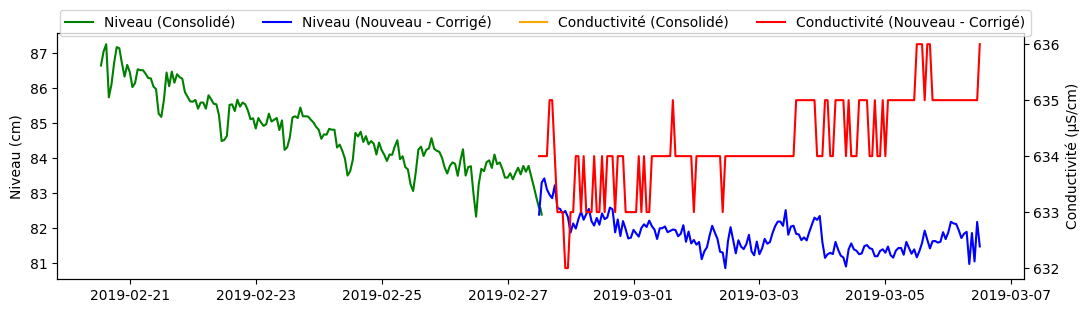

In [11]:
# Step 1: Load the old consolidated data (Excel file)
OLDDATA_PATH = r"Y:/MISSIONS/Eau/1 - Projet Hydrogéologique Ouysse/3 - Hydrodynamique/0 - Stations en continu/Ouysse - Calès/Gaetan"
olddatata_df = pd.read_excel(os.path.join(OLDDATA_PATH, "OuysseCales_consolide_old.xlsx"))

# Load the final_df (new data, from your previous CTD + Baro merge)
# Assuming 'final_df' is already created and available

# Ensure both dataframes have a 'DATE' column in datetime format
olddatata_df['DATE'] = pd.to_datetime(olddatata_df['DATE'])
final_df['DATE'] = pd.to_datetime(final_df['Date/time'])

# Step 2: Identify the junction dates
last_date_old = olddatata_df['DATE'].max()  # Last date in old data
first_date_new = final_df['DATE'].min()     # First date in new data

print(f"Last date in old data: {last_date_old}")
print(f"First date in new data: {first_date_new}")

# Step 3: Filter data around the junction (7 days before the last old date and 7 days after the first new date)
old_data_filtered = olddatata_df[olddatata_df['DATE'] >= (last_date_old - pd.Timedelta(days=7))]
new_data_filtered = final_df[final_df['DATE'] <= (first_date_new + pd.Timedelta(days=7))]

# Step 4: Calculate the shift for water level (Niveau)
dernier_niveau_old = old_data_filtered['Niveau'].dropna().iloc[-1]  # Last valid water level from old data
premier_niveau_new = new_data_filtered['Niveau_(cm)'].dropna().iloc[0]  # First valid water level from new data
shift_niveau = dernier_niveau_old - premier_niveau_new  # Calculate the shift

# Apply the shift to the new data for water level
final_df['Niveau_corr'] = final_df['Niveau_(cm)'] + shift_niveau

# Step 5: Calculate the shift for conductivity (Cond.)
derniere_cond_old = old_data_filtered['Conducti'].dropna().iloc[-1]  # Last valid conductivity from old data
premiere_cond_new = new_data_filtered['Cond_(µS/cm)'].dropna().iloc[0]  # First valid conductivity from new data
shift_cond = derniere_cond_old - premiere_cond_new  # Calculate the shift for conductivity

# Apply the shift to the new data for conductivity
final_df['Conducti_corr'] = final_df['Cond_(µS/cm)'] + shift_cond

# Step 6: Filter the corrected new data (same 7-day window)
new_data_filtered_corr = final_df[final_df['DATE'] <= (first_date_new + pd.Timedelta(days=7))]

# Step 7: Plot the corrected data along with the old data
fig, ax1 = plt.subplots(figsize=(11, 3))

# Plot corrected water level (Niveau)
ax1.plot(old_data_filtered['DATE'], old_data_filtered['Niveau'], label='Niveau (Consolidé)', color='green')
ax1.plot(new_data_filtered_corr['DATE'], new_data_filtered_corr['Niveau_corr'], label='Niveau (Nouveau - Corrigé)', color='blue')
ax1.set_ylabel('Niveau (cm)')
ax1.tick_params(axis='y')

# Plot corrected conductivity on the second axis
ax2 = ax1.twinx()
ax2.plot(old_data_filtered['DATE'], old_data_filtered['Conducti'], label='Conductivité (Consolidé)', color='orange')
ax2.plot(new_data_filtered_corr['DATE'], new_data_filtered_corr['Conducti_corr'], label='Conductivité (Nouveau - Corrigé)', color='red')
ax2.set_ylabel('Conductivité (µS/cm)')
ax2.tick_params(axis='y')

# Add legends and adjust layout
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)
plt.tight_layout()

# Display the plot
plt.show()


In [13]:
# Charger les données consolidées existantes
OLDDATA_PATH = r"Y:/MISSIONS/Eau/1 - Projet Hydrogéologique Ouysse/3 - Hydrodynamique/0 - Stations en continu/Ouysse - Calès/Gaetan"
old_data_path = os.path.join(OLDDATA_PATH, "OuysseCales_consolide_old.xlsx")
olddatata_df = pd.read_excel(old_data_path)

# Charger les nouvelles données corrigées (final_df)
final_df['DATE'] = pd.to_datetime(final_df['Date/time'])  # Conversion des dates
final_df_renamed = final_df[['DATE', 'Niveau_corr', 'Conducti_corr', 'Temp_(°C)']].rename(
    columns={'Niveau_corr': 'Niveau', 'Conducti_corr': 'Conducti', 'Temp_(°C)': 'Temp'}
)

# Fusionner les données
new_data_merged = pd.merge(
    olddatata_df, final_df_renamed, on='DATE', how='outer', suffixes=('_old', '')
)

# Compléter les données manquantes à partir des anciennes données
new_data_merged['Niveau'] = new_data_merged['Niveau'].combine_first(new_data_merged.get('Niveau_old'))
new_data_merged['Conducti'] = new_data_merged['Conducti'].combine_first(new_data_merged.get('Conducti_old'))
if 'Temp' in new_data_merged.columns:
    new_data_merged['Temp'] = new_data_merged['Temp'].combine_first(new_data_merged.get('Temp_old'))

# Supprimer les colonnes inutiles
columns_to_drop = ['Niveau_old', 'Conducti_old', 'Temp_old']
new_data_merged = new_data_merged.drop(columns=[col for col in columns_to_drop if col in new_data_merged.columns])

# Calculer le débit (Q) à partir de la colonne 'Niveau'
new_data_merged['Q'] = (
    7.7563 * (new_data_merged['Niveau'] / 100) ** 7.6404
)
new_data_merged.loc[new_data_merged['Niveau'] / 100 >= 1, 'Q'] = (
    10.227 * (new_data_merged['Niveau'] / 100) ** 2
    + 7.3348 * (new_data_merged['Niveau'] / 100)
    - 10
)

# Assurez-vous que 'Q' n'a pas de valeurs négatives
new_data_merged['Q'] = new_data_merged['Q'].apply(lambda x: max(x, 0) if pd.notna(x) else x)

# Sélectionner uniquement les colonnes nécessaires pour le fichier final
new_data_merged = new_data_merged[['DATE', 'Niveau', 'Conducti', 'Temp', 'Q']]

# Sauvegarder les résultats
output_path = os.path.join(OLDDATA_PATH, "OuysseCales_consolide_updated.xlsx")
new_data_merged.to_excel(output_path, index=False)
print(f"Données sauvegardées dans : {output_path}")


Données sauvegardées dans : Y:/MISSIONS/Eau/1 - Projet Hydrogéologique Ouysse/3 - Hydrodynamique/0 - Stations en continu/Ouysse - Calès/Gaetan\OuysseCales_consolide_updated.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the newly saved consolidated data
OLDDATA_PATH = r"Y:/MISSIONS/Eau/1 - Projet Hydrogéologique Ouysse/3 - Hydrodynamique/0 - Stations en continu/Ouysse - Calès/Gaetan"
new_consolidated_path = os.path.join(OLDDATA_PATH, "OuysseCales_consolide_updated.xlsx")
punctual_data_path = os.path.join(OLDDATA_PATH, "punctual_measurements.xlsx")

# Load the new consolidated data
new_consolidated_df = pd.read_excel(new_consolidated_path)
punctual_df = pd.read_excel(punctual_data_path)

# Ensure 'DATE' column in consolidated data and 'Jour' column in punctual data are in datetime format
new_consolidated_df['DATE'] = pd.to_datetime(new_consolidated_df['DATE'])
punctual_df['Datetime'] = pd.to_datetime(punctual_df['Jour'], dayfirst=True, errors='coerce')

# Plot the consolidated data (Niveau and Conductivity) as lines and the punctual data as points
fig, ax1 = plt.subplots(figsize=(11, 5))

# Plot water level (Niveau) from consolidated data as a line
ax1.plot(new_consolidated_df['DATE'], new_consolidated_df['Niveau'], label='Niveau (Consolidé)', color='green')
ax1.set_ylabel('Niveau (cm)')
ax1.set_xlabel('Datetime')
ax1.tick_params(axis='y')

# Plot punctual measurements for water level as points (control points)
ax1.scatter(punctual_df['Datetime'], punctual_df['Hauteur (cm)'], color='blue', label='point des controles Hauteur (cm)', marker='x')

# Add legends and adjust layout
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# Path to the newly saved consolidated data
NEW_CONSOLIDATED_PATH = os.path.join(r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx")
punctual_data_path = os.path.join(r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\punctual_measurements.xlsx")

# Load the new consolidated data
new_consolidated_df = pd.read_excel(NEW_CONSOLIDATED_PATH)
punctual_df = pd.read_excel(punctual_data_path)

# Ensure 'DATE' column in consolidated data and 'Jour' column in punctual data are in datetime format
new_consolidated_df['DATE'] = pd.to_datetime(new_consolidated_df['DATE'])
punctual_df['Datetime'] = pd.to_datetime(punctual_df['Jour'], dayfirst=True, errors='coerce')

# Create a Plotly figure
fig = go.Figure()

# Add scatter points for punctual measurements (control points)
fig.add_trace(go.Scatter(
    x=punctual_df['Datetime'],
    y=punctual_df['Hauteur (cm)'],
    mode='markers',
    name='Points de contrôle',
    marker=dict(color='blue', symbol='x')
))

# Add line for consolidated water level (Niveau)
fig.add_trace(go.Scatter(
    x=new_consolidated_df['DATE'],
    y=new_consolidated_df['Niveau'],
    mode='lines',
    name='Niveau_(cm)',
    line=dict(color='grey', width=2, dash='solid')
))

# Customize layout
fig.update_layout(
    xaxis_title='Datetime',
    yaxis_title='Niveau (cm)',
    legend_title='Légende',
    template='plotly_white'
)

# Show the figure
fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# Path to the newly saved consolidated data
NEW_CONSOLIDATED_PATH = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
)
punctual_data_path = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\punctual_measurements.xlsx"
)

# Load the new consolidated data
new_consolidated_df = pd.read_excel(NEW_CONSOLIDATED_PATH)
punctual_df = pd.read_excel(punctual_data_path)

# Ensure 'DATE' column in consolidated data and 'Jour' column in punctual data are in datetime format
new_consolidated_df['DATE'] = pd.to_datetime(new_consolidated_df['DATE'])
punctual_df['Datetime'] = pd.to_datetime(punctual_df['Jour'], dayfirst=True, errors='coerce')

# Apply corrections based on control points
for _, row in punctual_df.iterrows():
    point_date = row['Datetime']
    point_value = row['Hauteur (cm)']
    apply_correction = row.get("Correction", "Non")  # Assume "Non" if the column is missing

    if pd.isna(point_value) or apply_correction != "Oui":
        continue  # Skip points without correction or invalid values

    # Find the nearest measurement in consolidated data
    nearest_measure_index = (new_consolidated_df['DATE'] - point_date).abs().idxmin()
    nearest_measure_value = new_consolidated_df.at[nearest_measure_index, 'Niveau']

    # Check proximity (within 1 hour)
    if pd.isna(nearest_measure_value) or abs(
        (new_consolidated_df['DATE'][nearest_measure_index] - point_date).total_seconds()
    ) > 3600:
        continue

    # Calculate and apply the offset
    decalage = point_value - nearest_measure_value
    print(f"Date : {point_date}, Décalage appliqué : {decalage} cm")

    # Apply the offset to all subsequent measurements
    new_consolidated_df.loc[new_consolidated_df['DATE'] >= point_date, 'Niveau'] += decalage

# Create a Plotly figure
fig = go.Figure()

# Add scatter points for punctual measurements (control points)
corrected_color = ['red' if val == "Oui" else 'blue' for val in punctual_df['Correction']]
fig.add_trace(go.Scatter(
    x=punctual_df['Datetime'],
    y=punctual_df['Hauteur (cm)'],
    mode='markers',
    name='Points de contrôle',
    marker=dict(color=corrected_color, symbol='x', size=8)
))

# Add line for consolidated water level (Niveau) after correction
fig.add_trace(go.Scatter(
    x=new_consolidated_df['DATE'],
    y=new_consolidated_df['Niveau'],
    mode='lines',
    name='Niveau corrigé (cm)',
    line=dict(color='green', width=2, dash='solid')
))

# Customize layout
fig.update_layout(
    xaxis_title='Datetime',
    yaxis_title='Niveau (cm)',
    legend_title='Légende',
    template='plotly_white'
)

# Show the figure
fig.show()

# Save the corrected data to an Excel file
output_path = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
)
new_consolidated_df.to_excel(output_path, index=False)
print(f"Données corrigées sauvegardées dans : {output_path}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the newly saved consolidated data
OLDDATA_PATH = r"Y:/MISSIONS/Eau/1 - Projet Hydrogéologique Ouysse/3 - Hydrodynamique/0 - Stations en continu/Ouysse - Calès/Gaetan"
new_consolidated_path = os.path.join(OLDDATA_PATH, "OuysseCales_consolide_updated.xlsx")
punctual_data_path = os.path.join(OLDDATA_PATH, "punctual_measurements.xlsx")

# Load the new consolidated data
new_consolidated_df = pd.read_excel(new_consolidated_path)
punctual_df = pd.read_excel(punctual_data_path)

# Ensure 'DATE' column in consolidated data and 'Jour' column in punctual data are in datetime format
new_consolidated_df['DATE'] = pd.to_datetime(new_consolidated_df['DATE'])
punctual_df['Datetime'] = pd.to_datetime(punctual_df['Jour'], dayfirst=True, errors='coerce')

# Plot the consolidated data (Conductivity) as a line and the punctual data as points
fig, ax = plt.subplots(figsize=(11, 5))

# Plot conductivity from consolidated data as a line
ax.plot(new_consolidated_df['DATE'], new_consolidated_df['Conducti'], label='Conductivité (Consolidé)', color='orange')

# Plot punctual measurements for conductivity as points (control points)
ax.scatter(punctual_df['Datetime'], punctual_df['Conductivité'], color='red', label='Punctual Conductivité', marker='x')

# Set labels and titles
ax.set_ylabel('Conductivité (µS/cm)')
ax.set_xlabel('Datetime')

# Add legends and adjust layout
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# Chemin vers le fichier de données
data_path = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
)
punctual_data_path = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\punctual_measurements.xlsx"
)

# Charger les données
data = pd.read_excel(data_path)
punctual_df = pd.read_excel(punctual_data_path)

# Conversion des dates en datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')
punctual_df['Datetime'] = pd.to_datetime(punctual_df['Jour'], dayfirst=True, errors='coerce')

# Créer la colonne "Conductivité" avec comblement des données manquantes en utilisant seulement Conducti
if 'Conductivité' not in data.columns:
    data['Conductivité'] = data['Conducti'].copy()  # Copier les valeurs de Conducti directement dans Conductivité

# Appliquer les corrections uniquement pour les points marqués "Oui"
for index, row in punctual_df.iterrows():
    point_date = row['Datetime']
    point_value = row['Conductivité']
    apply_correction = row.get("Correction")  # Vérifier la colonne "Correction"

    if pd.isna(point_value) or apply_correction != "Oui":
        continue  # Passer les points sans correction ou avec valeur NaN

    # Trouver la mesure la plus proche dans les données consolidées
    nearest_measure_index = (data['DATE'] - point_date).abs().idxmin()
    nearest_measure_value = data.at[nearest_measure_index, 'Conductivité']

    # Si la mesure est trop éloignée dans le temps, ne pas appliquer la correction
    if abs((data['DATE'][nearest_measure_index] - point_date).total_seconds()) > 3600:
        continue

    # Calculer le décalage et l'appliquer aux données après ce point de contrôle
    decalage = point_value - nearest_measure_value
    print(f"Date : {point_date}, Décalage appliqué : {decalage} µS/cm")

    # Appliquer le décalage à toutes les mesures après la date du point de contrôle
    data.loc[data['DATE'] >= point_date, 'Conductivité'] += decalage

# Visualisation interactive avec Plotly
fig = go.Figure()

# Tracer les données de Conducti et Conductivité corrigée
fig.add_trace(go.Scatter(x=data['DATE'], y=data['Conducti'], mode='lines', name='Conductivité', line=dict(color='orange')))
#fig.add_trace(go.Scatter(x=data['DATE'], y=data['Conductivité'], mode='lines', name='Conductivité corrigée', line=dict(color='green')))

# Ajouter les points de contrôle
fig.add_trace(go.Scatter(
    x=punctual_df['Datetime'],
    y=punctual_df['Conductivité'],
    mode='markers',
    name='Points de contrôle',
    marker=dict(symbol='x', color='red', size=8)
))

# Configuration du graphique
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Conductivité (µS/cm)',
    legend_title='Type de mesure'
)

# Exporter le graphique pour inspection
html_output_path = (r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\\Ouysse - Calès\Gaetan\Graphique_conductivté et points_de_controles.html")
fig.write_html(html_output_path)
print(f"Graphique interactif sauvegardé dans : {html_output_path}")

# Afficher le graphique
fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# Chemin vers le fichier de données
data_path = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
)

# Charger les données principales
data = pd.read_excel(data_path)

# Conversion des dates en datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Vérifier que Conducti existe et créer les colonnes pour les versions nettoyées
if 'Conducti' in data.columns:
    data['Conductivité_originale'] = data['Conducti'].copy()
else:
    raise KeyError("La colonne 'Conducti' n'existe pas dans le fichier de données.")

data['Conductivité_nettoyee'] = data['Conductivité_originale'].copy()

# Définir les périodes spécifiques pour suppression
periods_to_remove = [
    ("2021-01-23 12:00", "2021-01-26 15:00"),
    ("2021-01-29 08:00", "2021-02-04 16:00"),
    ("2021-02-10 03:00", "2021-02-14 14:00"),
    ("2023-11-03 00:00", "2023-11-07 07:00"),
    ("2023-11-09 21:00", "2023-11-14 02:00"),
    ("2023-12-11 09:00", "2023-12-15 08:00"),
    ("2024-05-01 13:00", "2024-05-09 19:00")
    
]

# Supprimer les données de ces périodes en les remplaçant par NaN
for start, end in periods_to_remove:
    mask = (data['DATE'] >= pd.to_datetime(start)) & (data['DATE'] <= pd.to_datetime(end))
    data.loc[mask, 'Conductivité_nettoyee'] = None

# Appliquer le filtre IQR sur une fenêtre glissante pour détecter les outliers
window_size = '500H'  # Fenêtre de 48 heures
for i in range(len(data)):
    # Définir la fenêtre de temps autour de chaque point
    start_date = data['DATE'].iloc[i] - pd.Timedelta(window_size)
    end_date = data['DATE'].iloc[i] + pd.Timedelta(window_size)
    
    # Extraire les données dans cette fenêtre
    window_data = data[(data['DATE'] >= start_date) & (data['DATE'] <= end_date)]['Conductivité_nettoyee'].dropna()
    
    # Calculer le IQR et définir les bornes pour filtrer les outliers
    Q1 = window_data.quantile(0.25)
    Q3 = window_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 0.8 * IQR
    upper_bound = Q3 + 0.8 * IQR
    
    # Filtrer les outliers : si en dehors des bornes, marquer comme NaN
    if data['Conductivité_nettoyee'].iloc[i] < lower_bound or data['Conductivité_nettoyee'].iloc[i] > upper_bound:
        data.at[i, 'Conductivité_nettoyee'] = None

# Interpoler les valeurs manquantes dans les données nettoyées après le filtre IQR
data.set_index('DATE', inplace=True)
data['Conductivité_nettoyee'] = data['Conductivité_nettoyee'].interpolate(method='time')
data.reset_index(inplace=True)

# Visualisation interactive avec Plotly
fig = go.Figure()

# Ajouter les données d'origine
fig.add_trace(go.Scatter(
    x=data['DATE'], y=data['Conductivité_originale'],
    mode='lines', name='Conductivité (originale)',
    line=dict(color='orange')
))

# Ajouter les données nettoyées après suppression et filtre IQR
fig.add_trace(go.Scatter(
    x=data['DATE'], y=data['Conductivité_nettoyee'],
    mode='lines', name='Conductivité (nettoyée après suppression et IQR)',
    line=dict(color='blue')
))

# Configuration du graphique
fig.update_layout(
    title='Visualisation des données de conductivité avec suppression des périodes spécifiques et filtre IQR',
    xaxis_title='Date',
    yaxis=dict(title='Conductivité (µS/cm)'),
    legend_title='Type de mesure'
)

# Exporter le graphique pour inspection
html_output_path = (r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.html"
)
fig.write_html(html_output_path)
print(f"Graphique interactif sauvegardé dans : {html_output_path}")

# Sauvegarder les données nettoyées dans un fichier Excel
output_path = os.path.join(
    r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
)
data.to_excel(output_path, index=False)
print(f"Données nettoyées sauvegardées dans : {output_path}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Chemins vers les fichiers
data_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
rainfall_data_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\Pluie_BV_Ouysse.csv"

# Charger les données
data = pd.read_excel(data_path)
rainfall_data = pd.read_csv(rainfall_data_path)

# Conversion des dates en datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')
rainfall_data['Date'] = pd.to_datetime(rainfall_data['Date'], errors='coerce')

# Calculer la moyenne mobile pour la température et la conductivité
data['Temp_Moving_Avg'] = data['Temp'].rolling(window=24, center=True).mean()
data['Conductivité_Moving_Avg'] = data['Conductivité_nettoyee'].rolling(window=24, center=True).mean()

# Ajustement des dates pour la plage des données
start_date = data['DATE'].min() - pd.Timedelta(days=7)
end_date = data['DATE'].max() + pd.Timedelta(days=7)

rainfall_data = rainfall_data[(rainfall_data['Date'] >= start_date) & (rainfall_data['Date'] <= end_date)]
data = data[(data['DATE'] >= start_date) & (data['DATE'] <= end_date)]

# Création du graphique
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={'hspace': 0.1})

# --- Graphe 1 : Débit et Précipitations ---
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.plot(data['DATE'], data['Q'], color='lightseagreen')
ax1.set_ylabel('Débit (m³/s)', color='lightseagreen')
ax1.tick_params(axis='y', labelcolor='lightseagreen')

ax2.bar(
    rainfall_data['Date'], rainfall_data['Precipitation (mm)'],
    width=0.8, color='royalblue', label='Précipitations (mm)', align='center'
)
ax2.invert_yaxis()  # Inverser l'axe des précipitations
ax2.set_ylabel('Précipitations (mm)', color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')

# --- Graphe 2 : Conductivité corrigée et Température ---
ax3 = axes[1]
ax4 = ax3.twinx()

ax3.plot(data['DATE'], data['Conductivité_Moving_Avg'], color='black', label='Conductivité (µS/cm)')
ax3.set_ylabel('Conductivité corrigée (µS/cm)', color='black')
ax3.tick_params(axis='y', labelcolor='black')

ax4.plot(data['DATE'], data['Temp_Moving_Avg'], color='crimson', label='Température (°C)')
ax4.set_ylabel('Température (°C)', color='crimson')
ax4.tick_params(axis='y', labelcolor='crimson')

# Ajustement des marges et sauvegarde
plt.subplots_adjust(hspace=0.2)
svg_output_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\Graphique_Debit_Temp_Conductivite_with_Rainfall.svg"
plt.savefig(svg_output_path, format='svg', dpi=300)
print(f"Graphique sauvegardé en SVG à : {svg_output_path}")

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import os

# Charger les données
data_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
data = pd.read_excel(data_path)

# Conversion de la colonne 'DATE' en datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Vérifier et supprimer les doublons
if data['DATE'].duplicated().any():
    print(f"Attention : {data['DATE'].duplicated().sum()} doublons détectés. Ils seront supprimés.")
    data = data.drop_duplicates(subset='DATE')

# Réindexer pour inclure toutes les heures
date_range = pd.date_range(start=data['DATE'].min(), end=data['DATE'].max(), freq='H')
data = data.set_index('DATE').reindex(date_range).reset_index()
data.rename(columns={'index': 'DATE'}, inplace=True)

# Ajouter une colonne pour indiquer les valeurs manquantes
data['Manquante'] = data.isnull().any(axis=1).astype(int)

# Identifier les groupes de trous consécutifs
data['Groupe'] = (data['Manquante'] != data['Manquante'].shift()).cumsum()

# Calculer la taille des groupes
groupe_sizes = data.groupby('Groupe')['Manquante'].sum()

# Identifier les groupes de trous longs (>12h)
trous_longs = groupe_sizes[groupe_sizes > 12].index

# Appliquer une interpolation globale
cols_to_interpolate = data.select_dtypes(include=[np.number]).columns.difference(['Manquante', 'Groupe'])
data[cols_to_interpolate] = data[cols_to_interpolate].interpolate(method='linear', limit_direction='both')

# Supprimer les interpolations pour les trous longs
data.loc[data['Groupe'].isin(trous_longs), cols_to_interpolate] = np.nan

# Ajouter une colonne Statut
data['Statut'] = 'Brute'
data.loc[data['Manquante'] == 1, 'Statut'] = 'Manquante'
data.loc[(data['Manquante'] == 1) & ~data['Groupe'].isin(trous_longs), 'Statut'] = 'Interpolée'

# Nettoyer les colonnes auxiliaires
data = data.drop(columns=['Manquante', 'Groupe'])

# Sauvegarder les données
output_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_interpolated_fixed.xlsx"
data.to_excel(output_path, index=False)

print(f"Données interpolées sauvegardées dans : {output_path}")


In [ ]:
# Charger les données
data_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_consolide_updated.xlsx"
data = pd.read_excel(data_path)

# Conversion de la colonne 'DATE' en datetime
data['DATE'] = pd.to_datetime(data['DATE'], errors='coerce')

# Supprimer les doublons sur DATE
data = data.drop_duplicates(subset='DATE')

# Réindexer avec toutes les heures manquantes
date_range = pd.date_range(start=data['DATE'].min(), end=data['DATE'].max(), freq='H')
data = data.set_index('DATE').reindex(date_range).reset_index()
data.rename(columns={'index': 'DATE'}, inplace=True)

# Récupérer toutes les colonnes sauf "DATE"
colonnes_a_interpoler = data.select_dtypes(include=[np.number]).columns

# Dictionnaire pour stocker les statuts par colonne
statuts = pd.DataFrame({'DATE': data['DATE']})

for col in colonnes_a_interpoler:
    print(f"Traitement de la colonne : {col}")

    # Identifier les valeurs manquantes pour cette colonne
    data[f'Manquante_{col}'] = data[col].isnull().astype(int)

    # Détecter les groupes de valeurs manquantes
    data[f'Groupe_{col}'] = (data[f'Manquante_{col}'] != data[f'Manquante_{col}'].shift()).cumsum()
    groupe_sizes = data.groupby(f'Groupe_{col}')[f'Manquante_{col}'].sum()
    trous_longs = groupe_sizes[groupe_sizes > 12].index  # Groupes avec >12h de trous

    # Appliquer l'interpolation pour cette colonne
    data[col] = data[col].interpolate(method='linear', limit_direction='both')

    # Supprimer les interpolations pour les trous longs
    data.loc[data[f'Groupe_{col}'].isin(trous_longs), col] = np.nan

    # Ajouter le statut spécifique à cette colonne
    statut_col = f'Statut_{col}'
    statuts[statut_col] = 'Brute'
    statuts.loc[data[col].isnull(), statut_col] = 'Manquante'
    statuts.loc[(data[col].notnull()) & (data[f'Manquante_{col}'] == 1), statut_col] = 'Interpolée'

# Nettoyer les colonnes auxiliaires
cols_to_remove = [col for col in data.columns if col.startswith(('Manquante_', 'Groupe_'))]
data = data.drop(columns=cols_to_remove)

# Fusionner les statuts avec les données finales
data = data.merge(statuts, on="DATE", how="left")

# Sauvegarde
output_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_interpolé.xlsx"
data.to_excel(output_path, index=False)

print(f"✅ Fichier sauvegardé : {output_path}")


In [ ]:
import pandas as pd
import plotly.express as px
import os

# Charger les données interpolées
data_interpolated_path = r"Y:\MISSIONS\Eau\1 - Projet Hydrogéologique Ouysse\3 - Hydrodynamique\0 - Stations en continu\Ouysse - Calès\Gaetan\OuysseCales_interpolated_fixed.xlsx"
data_interpolated = pd.read_excel(data_interpolated_path)

# Créer un graphique interactif pour visualiser la différence entre les valeurs brutes et interpolées
fig = px.scatter(
    data_interpolated,
    x="DATE",
    y="Niveau",
    color="Statut",  # Différencie entre "Interpolée" et "Brute"
    title="Différence entre les valeurs brutes et interpolées",
    labels={"Niveau_m": "Niveau (m)", "DATE": "Date"},
    color_discrete_map={"Brute": "blue", "Interpolée": "red"}
)

# Configurer l'apparence du graphique
fig.update_traces(mode="markers")  # Affiche uniquement des points (pas de lignes)
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Niveau (m)",
    legend_title="Statut",
    template="plotly_white"
)

fig.show()
